# Bayesian VAR Model on China's Crude Oil Market

This notebook decomposes the China's crude oil market shocks into three components: supply, demand, and precautionary demand shock. The model is based on the Bayesian version of Kilian (2007) VAR Model with NIW prior and Gibbs sampling.

The objective is to determine the regime of the China's crude oil market.

## Setup

In [85]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import invwishart
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(suppress=True, precision=4)

## Load the Kilian VAR data

### The CPI data of 2025 oct is NaN because the government shutdown in 2025, so we truncate the series before 2025 october

In [86]:
import sys
sys.path.append('./src')
from irf_bootstraps import *
from post_draw_ci import *
from bvar_helper import *
from gibbs_bvar_niw import *

df = pd.read_csv('data/BVAR_data.csv', parse_dates=['date'])

# filter out the data before 2018 march, when SC was not in effect
df = df[df['date'] >= '2018-03-01'].copy()
df.reset_index(drop=True, inplace=True)

df.head(),df.tail(),df.shape

(        date     d_prod        rea         rpo
 0 2018-03-01  -1.238508 -29.648143  138.415532
 1 2018-04-01  -3.916089 -31.931258  144.136263
 2 2018-05-01  -1.222621 -18.426342  150.503023
 3 2018-06-01   2.426313 -13.887253  155.114613
 4 2018-07-01  10.406368   6.120901  158.480233,
          date     d_prod        rea         rpo
 89 2025-08-01   6.464529  14.343198  143.937082
 90 2025-09-01  15.695441  20.231109  142.797055
 91 2025-10-01  -0.319303  14.042464  138.320605
 92 2025-11-01  -1.552829  23.099194  137.268655
 93 2025-12-01  -2.678216  29.825566  132.369809,
 (94, 4))

## Data Summary and diagnostics



In [87]:
print(df.describe())
print(df.isnull().sum())
print(df.isna().sum())


                             date      d_prod         rea         rpo
count                          94   94.000000   94.000000   94.000000
mean   2022-01-15 08:56:10.212766    0.559808   -5.470636  145.556656
min           2018-03-01 00:00:00 -173.885832 -121.364790   69.717854
25%           2020-02-08 06:00:00   -6.220927  -26.402848  137.884370
50%           2022-01-16 12:00:00    2.680701   -2.763361  149.464793
75%           2023-12-24 06:00:00    9.492774   18.231693  160.856766
max           2025-12-01 00:00:00   30.203683  110.231940  188.854792
std                           NaN   21.592166   43.597254   25.102416
date      0
d_prod    0
rea       0
rpo       0
dtype: int64
date      0
d_prod    0
rea       0
rpo       0
dtype: int64


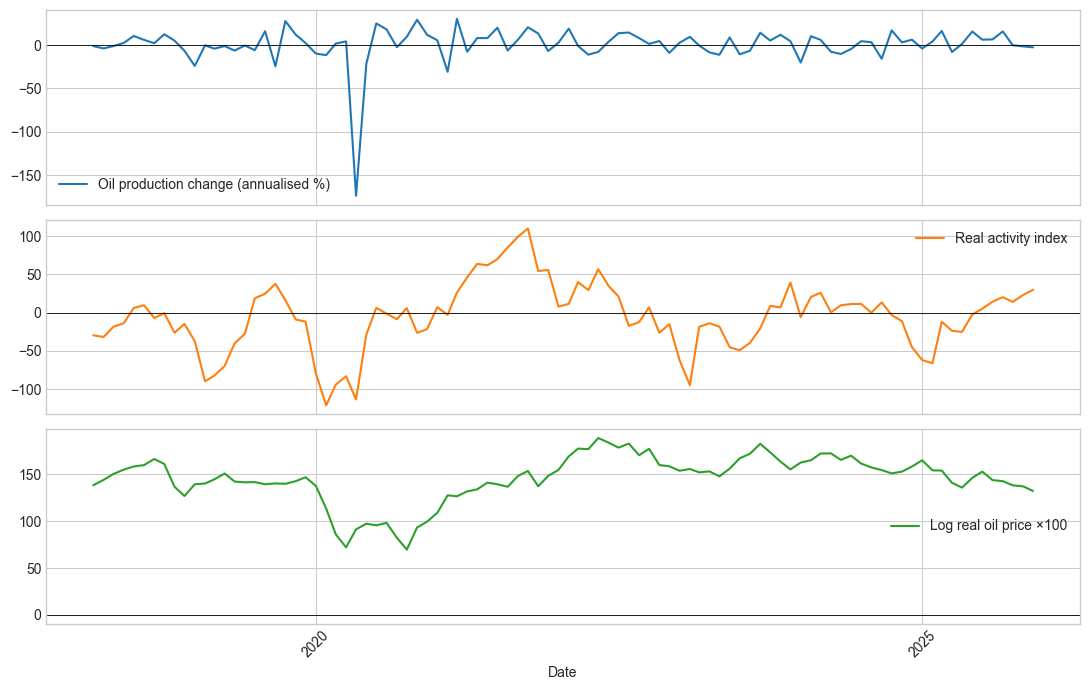

In [88]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

axes[0].plot(df['date'], df['d_prod'], label='Oil production change (annualised %)')
axes[0].axhline(0, color='k', lw=0.6)
axes[0].legend()

axes[1].plot(df['date'], df['rea'], label='Real activity index', color='tab:orange')
axes[1].axhline(0, color='k', lw=0.6)
axes[1].legend()

axes[2].plot(df['date'], df['rpo'], label='Log real oil price ×100', color='tab:green')
axes[2].axhline(0, color='k', lw=0.6)
axes[2].legend()

axes[2].xaxis.set_major_locator(mdates.YearLocator(5))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[2].tick_params(axis='x', rotation=45)

axes[2].set_xlabel('Date')
plt.tight_layout()
plt.show()

## Stationarity checks (ADF and KPSS)

In [89]:
rows = []
cols = ['d_prod', 'rea', 'rpo']
alpha = 0.05
for c in cols:
    s = df[c].dropna().values
    adf = adfuller(s, regression='c', autolag='AIC')
    kps = kpss(s, regression='c', nlags='auto')
    rows.append({
        'series': c,
        'adf_stat': adf[0],
        'adf_pvalue': adf[1],
        'adf_reject_5pct': adf[1] < alpha,
        'kpss_stat': kps[0],
        'kpss_pvalue': kps[1],
        'kpss_reject_5pct': kps[1] < alpha,
    })
print(f"ADF H0: unit root nonstationary, KPSS H0: trend-stationarity")
stationarity_table = pd.DataFrame(rows)
stationarity_table

ADF H0: unit root nonstationary, KPSS H0: trend-stationarity


/var/folders/3g/9jy95tfs3s11qr_9lw9l2dsm0000gn/T/ipykernel_59297/4034603095.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kps = kpss(s, regression='c', nlags='auto')
/var/folders/3g/9jy95tfs3s11qr_9lw9l2dsm0000gn/T/ipykernel_59297/4034603095.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kps = kpss(s, regression='c', nlags='auto')


,series,adf_stat,adf_pvalue,adf_reject_5pct,kpss_stat,kpss_pvalue,kpss_reject_5pct
0,d_prod,-9.037116,5.252761e-15,True,0.115568,0.100000,False
1,rea,-2.972751,3.751867e-02,True,0.161841,0.100000,False
2,rpo,-2.171759,2.166545e-01,False,0.434757,0.062174,False


## AIC table by lag length

In [90]:
aic_rows = []
bic_rows = []
hqic_rows = []
for lag in range(1, 26):
    try:
        res = VAR(df[cols]).fit(lag)
        aic_rows.append({'lag': lag, 'AIC': res.aic})
        bic_rows.append({'lag': lag, 'BIC': res.bic})
        hqic_rows.append({'lag': lag, 'HQIC': res.hqic})
    except Exception:
        aic_rows.append({'lag': lag, 'AIC': np.nan})
aic_table = pd.DataFrame(aic_rows, columns=['lag', 'AIC'])
bic_table = pd.DataFrame(bic_rows, columns=['lag', 'BIC'])
hqic_table = pd.DataFrame(hqic_rows, columns=['lag', 'HQIC'])

model_selection_table = pd.concat([aic_table, bic_table, hqic_table], axis=1)

# print("Lag with minimum info criteria:", model_selection_table.idxmin(axis=1))
model_selection_table

,lag,AIC,lag,BIC,lag,HQIC
0,1,16.976698,1,17.303485,1,17.108645
1,2,17.065451,2,17.641077,2,17.297778
2,3,17.102147,3,17.929903,3,17.436095
3,4,17.205911,4,18.289162,4,17.642741
4,5,17.235061,5,18.577247,5,17.776057
5,6,17.261477,6,18.866116,6,17.907946
6,7,17.303577,7,19.174266,7,18.056846
7,8,17.425622,8,19.566041,8,18.287041
8,9,17.358516,9,19.772430,9,18.329460
9,10,17.578887,10,20.270149,10,18.660752


## BVAR(24) with NIW prior and Gibbs sampling

In [91]:
p = 6
n_draws = 12000
burn = 2000

# df[cols].values produces a pure float64 array — required for matrix arithmetic
bvar = gibbs_bvar_niw(df[cols].values.astype(float), p=p, n_draws=n_draws, burn=burn, seed=42)
bvar['B_mean'].shape, bvar['Sigma_mean']

((19, 3),
 array([[280.2481,  57.7903, -39.5563],
        [ 57.7903, 491.2011,  17.7589],
        [-39.5563,  17.7589,  69.025 ]]))

## MCMC trace plots (visual convergence check)

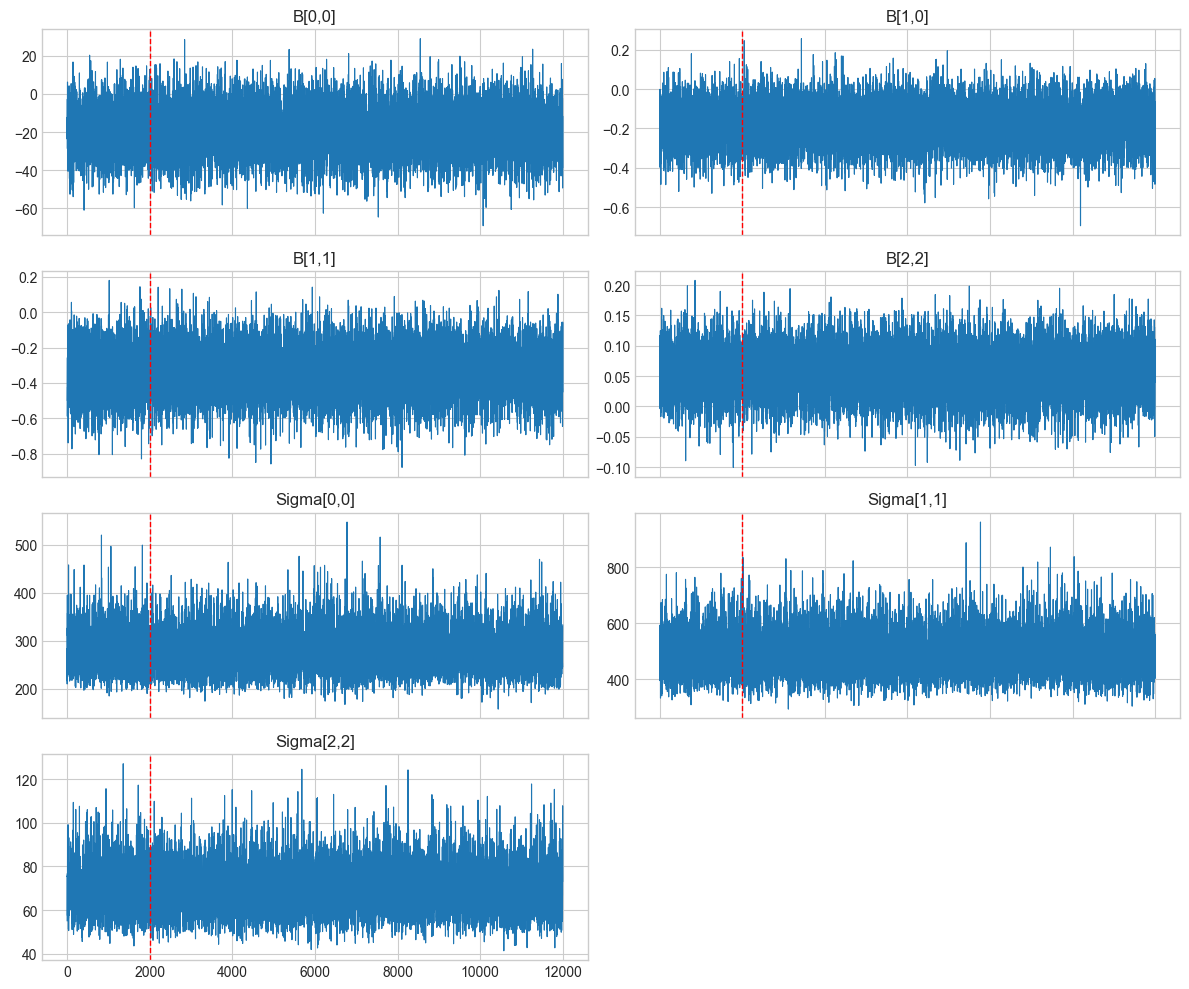

In [92]:
fig, axes = plt.subplots(4, 2, figsize=(12, 10), sharex=True)
axes = axes.ravel()

trace_names = ['B[0,0]', 'B[1,0]', 'B[1,1]', 'B[2,2]']
for i in range(4):
    axes[i].plot(bvar['B_trace'][:, i], lw=0.8)
    axes[i].axvline(2000, color='r', ls='--', lw=1)
    axes[i].set_title(trace_names[i])

sig_names = ['Sigma[0,0]', 'Sigma[1,1]', 'Sigma[2,2]']
for i in range(3):
    axes[4+i].plot(bvar['S_trace'][:, i], lw=0.8)
    axes[4+i].axvline(2000, color='r', ls='--', lw=1)
    axes[4+i].set_title(sig_names[i])

axes[-1].axis('off')
plt.tight_layout()
plt.show()

## Residual diagnostics (Ljung-Box test)

In [93]:
Y = bvar['Y']
X = bvar['X']
Bhat = bvar['B_mean']
resid = Y - X @ Bhat

lb_rows = []
for i, c in enumerate(cols):
    lb = acorr_ljungbox(resid[:, i], lags=[24], return_df=True)
    lb_rows.append({
        'series': c,
        'lb_stat_lag12': float(lb['lb_stat'].iloc[0]),
        'lb_pvalue_lag12': float(lb['lb_pvalue'].iloc[0]),
        'reject_5pct': lb['lb_pvalue'].iloc[0] < 0.05
    })
print(f"Ljung-Box test H0: no serial correlation")
ljung_box_table = pd.DataFrame(lb_rows)
ljung_box_table

Ljung-Box test H0: no serial correlation


,series,lb_stat_lag12,lb_pvalue_lag12,reject_5pct
0,d_prod,24.972848,0.407237,False
1,rea,26.887451,0.309727,False
2,rpo,13.640981,0.954348,False


## Running posterior mean over iterations

This plots the cumulative posterior mean (after burn-in) to visually inspect stabilization over MCMC draws.

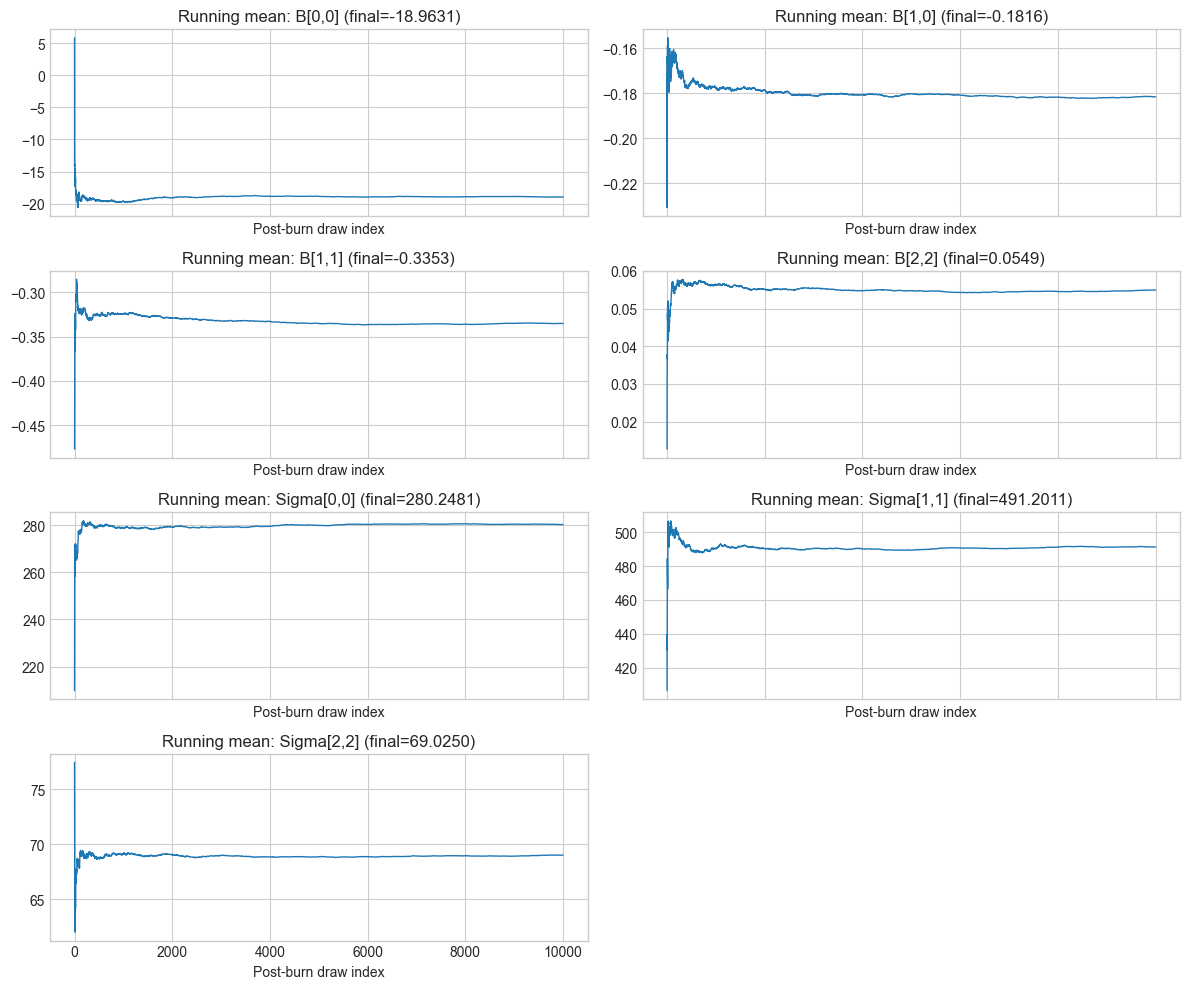

In [94]:
keep_B = bvar['B_draws']
keep_S = bvar['Sigma_draws']

cum_mean_B00 = np.cumsum(keep_B[:, 0, 0]) / np.arange(1, keep_B.shape[0] + 1)
cum_mean_B10 = np.cumsum(keep_B[:, 1, 0]) / np.arange(1, keep_B.shape[0] + 1)
cum_mean_B11 = np.cumsum(keep_B[:, 1, 1]) / np.arange(1, keep_B.shape[0] + 1)
cum_mean_B22 = np.cumsum(keep_B[:, 2, 2]) / np.arange(1, keep_B.shape[0] + 1)

cum_mean_S00 = np.cumsum(keep_S[:, 0, 0]) / np.arange(1, keep_S.shape[0] + 1)
cum_mean_S11 = np.cumsum(keep_S[:, 1, 1]) / np.arange(1, keep_S.shape[0] + 1)
cum_mean_S22 = np.cumsum(keep_S[:, 2, 2]) / np.arange(1, keep_S.shape[0] + 1)

fig, axes = plt.subplots(4, 2, figsize=(12, 10), sharex=True)
axes = axes.ravel()

series = [
    (cum_mean_B00, 'Running mean: B[0,0]'),
    (cum_mean_B10, 'Running mean: B[1,0]'),
    (cum_mean_B11, 'Running mean: B[1,1]'),
    (cum_mean_B22, 'Running mean: B[2,2]'),
    (cum_mean_S00, 'Running mean: Sigma[0,0]'),
    (cum_mean_S11, 'Running mean: Sigma[1,1]'),
    (cum_mean_S22, 'Running mean: Sigma[2,2]'),
]

for i, (s, ttl) in enumerate(series):
    axes[i].plot(s, lw=1)
    axes[i].set_title(f"{ttl} (final={s[-1]:.4f})")
    axes[i].set_xlabel('Post-burn draw index')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

## Posterior estimates (intercept, lag-1, residuals)

Reduced-form BVAR equation $Y_t = X_t B + u_t$ with $u_t \sim \mathcal{N}(0,\Sigma)$.
The table reports posterior means and 95% credible intervals from post-burn-in Gibbs draws.
Structural shocks are identified later via Cholesky factorization of $\Sigma$ (Kilian ordering).

In [95]:
from posterior_table import posterior_bvar_summary, posterior_bvar_latex

n = bvar['B_draws'].shape[2]  # number of endogenous variables
post_summary = posterior_bvar_summary(
    bvar['B_draws'],
    bvar['Sigma_draws'],
    n=n,
)
display(post_summary.round(3))

notes = (
    f"Based on {bvar['B_draws'].shape[0]:,} post-burn-in draws "
    f"(burn-in = {burn:,}, total = {n_draws:,}). "
    "Endogenous order: oil production, real activity, real oil price. "
    r"$\Sigma_{ij}$ denotes the $(i,j)$ element of the reduced-form innovation covariance."
)
notes

,block,equation,parameter,mean,sd,ci_lo,ci_hi
0,Intercept,Oil production,Constant,-18.963,12.396,-43.737,5.116
1,Intercept,Real activity,Constant,14.631,16.337,-17.210,46.882
2,Intercept,Real oil price,Constant,11.241,6.092,-0.773,23.142
3,Lag-1,Oil production,$\Delta prod_{t-1}$,-0.182,0.106,-0.387,0.024
4,Lag-1,Oil production,$rea_{t-1}$,-0.053,0.080,-0.211,0.102
5,Lag-1,Oil production,$rpo_{t-1}$,0.276,0.220,-0.152,0.710
6,Lag-1,Real activity,$\Delta prod_{t-1}$,-0.335,0.139,-0.610,-0.068
7,Lag-1,Real activity,$rea_{t-1}$,0.843,0.105,0.637,1.054
8,Lag-1,Real activity,$rpo_{t-1}$,0.116,0.297,-0.461,0.703
9,Lag-1,Real oil price,$\Delta prod_{t-1}$,0.003,0.051,-0.098,0.104


'Based on 10,000 post-burn-in draws (burn-in = 2,000, total = 12,000). Endogenous order: oil production, real activity, real oil price. $\\Sigma_{ij}$ denotes the $(i,j)$ element of the reduced-form innovation covariance.'

## Bayesian Figure 2: structural shocks (posterior mean parameters)

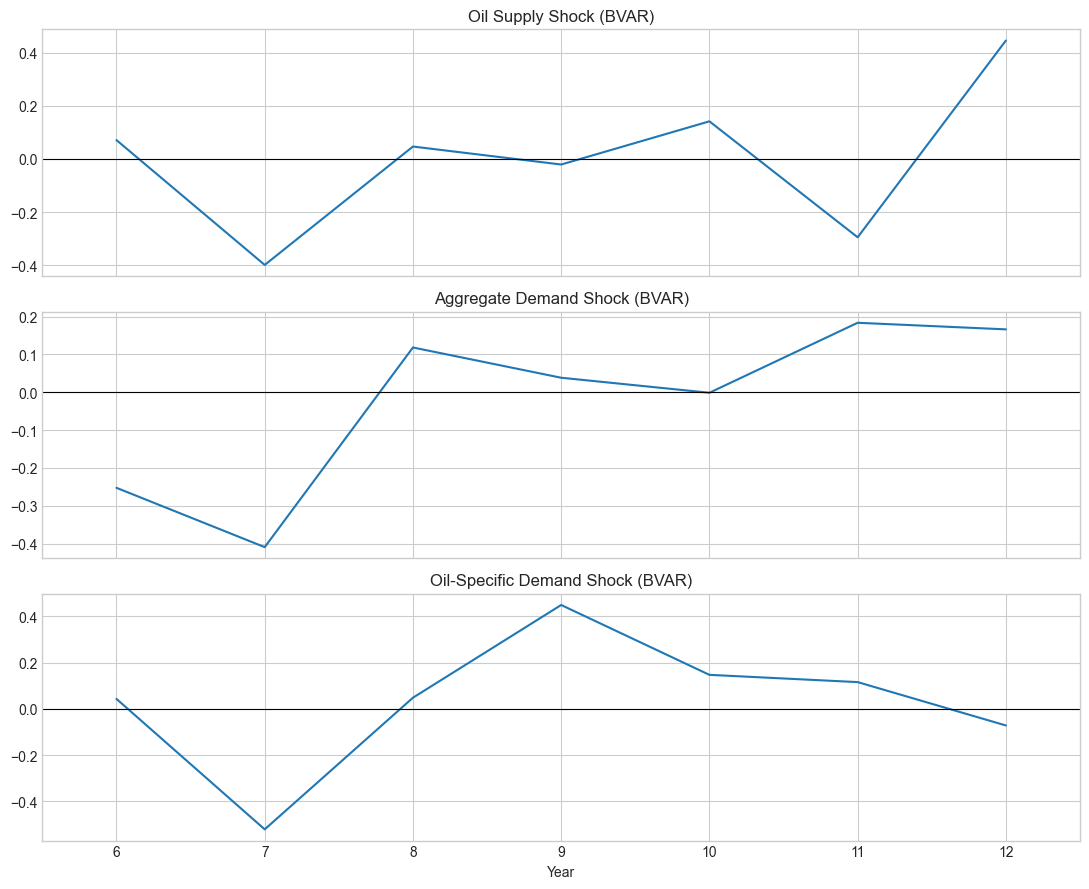

Showing annual averages for 7 complete years (6–12)


In [96]:
n = 3
h = 15

# Use only numeric columns — df[cols].values is float64
y = df[cols].values.astype(float)
Ehat_b = structural_shocks_from_bmean(y, bvar['B_mean'], bvar['Sigma_mean'], p=p)

# Date axis: shocks start after p lags; df.index[p] is the first observation used
shock_dates = df.index[p:]

# Annual averages of monthly structural shocks
# We can only use complete 12-month blocks
n_shocks = Ehat_b.shape[1]  # number of shock observations available
n_full_years = n_shocks // 12
n_months_to_use = n_full_years * 12

year_min = shock_dates[0]
time_year = np.arange(year_min, year_min + n_full_years)

def annual_avg(shock_row, n_months):
    """Average monthly shocks over complete years."""
    return shock_row[:n_months].reshape(-1, 12).mean(axis=1)

q1a = annual_avg(Ehat_b[0], n_months_to_use)
q2a = annual_avg(Ehat_b[1], n_months_to_use)
q3a = annual_avg(Ehat_b[2], n_months_to_use)

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for ax, s, ttl in zip(
    axes,
    [q1a, q2a, q3a],
    ['Oil Supply Shock (BVAR)', 'Aggregate Demand Shock (BVAR)', 'Oil-Specific Demand Shock (BVAR)']
):
    ax.plot(time_year, s) # use line plot instead
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xlim(year_min - 0.5, time_year[-1] + 0.5)
    ax.set_title(ttl)

axes[-1].set_xlabel('Year')
plt.tight_layout()
plt.show()

print(f"Showing annual averages for {n_full_years} complete years ({year_min}–{time_year[-1]})")

In [97]:
# Table: Cholesky-identified structural innovations (4-col: Equation, Regressor, Mean, 95% CI)
# eps_t = C^{-1} u_t,  u_t = y_t - X_t B,  C = chol(Sigma)' (Kilian ordering)
from structural_shock_table import (
    structural_innovations_posterior_table,
    structural_innovations_latex,
)

shock_table = structural_innovations_posterior_table(
    y, bvar['B_draws'], bvar['Sigma_draws'], p=p, max_draws=2000,
)
display(shock_table.round(4))

notes_shocks = (
    r"Sample covariance of $\hat\varepsilon_t$ at each Gibbs draw; "
    r"$\hat\varepsilon_t=\hat C^{-1}\hat u_t$ with $\hat C=\mathrm{chol}(\hat\Sigma)'$. "
    f"Ordering: oil production, real activity, real oil price. "
    "95% credible intervals from 2,000 thinned post-burn-in draws."
)
notes_shocks

,equation,parameter,mean,ci_lo,ci_hi
0,oil supply shock,$\Sigma_{11}$,1.1561,0.8777,1.4920
1,commodity agg. demand shock,$\Sigma_{21}$,-0.0434,-0.3797,0.2775
2,commodity agg. demand shock,$\Sigma_{22}$,1.2814,0.9526,1.6566
3,oil specific demand shock,$\Sigma_{33}$,1.4184,1.0789,1.8049
4,oil specific demand shock,$\Sigma_{31}$,-0.1846,-0.3329,-0.0384
5,oil specific demand shock,$\Sigma_{32}$,0.0497,-0.0673,0.1743


"Sample covariance of $\\hat\\varepsilon_t$ at each Gibbs draw; $\\hat\\varepsilon_t=\\hat C^{-1}\\hat u_t$ with $\\hat C=\\mathrm{chol}(\\hat\\Sigma)'$. Ordering: oil production, real activity, real oil price. 95% credible intervals from 2,000 thinned post-burn-in draws."

## Bayesian Figure 3: IRFs and credible intervals from posterior draws

IRFs at horizon 15


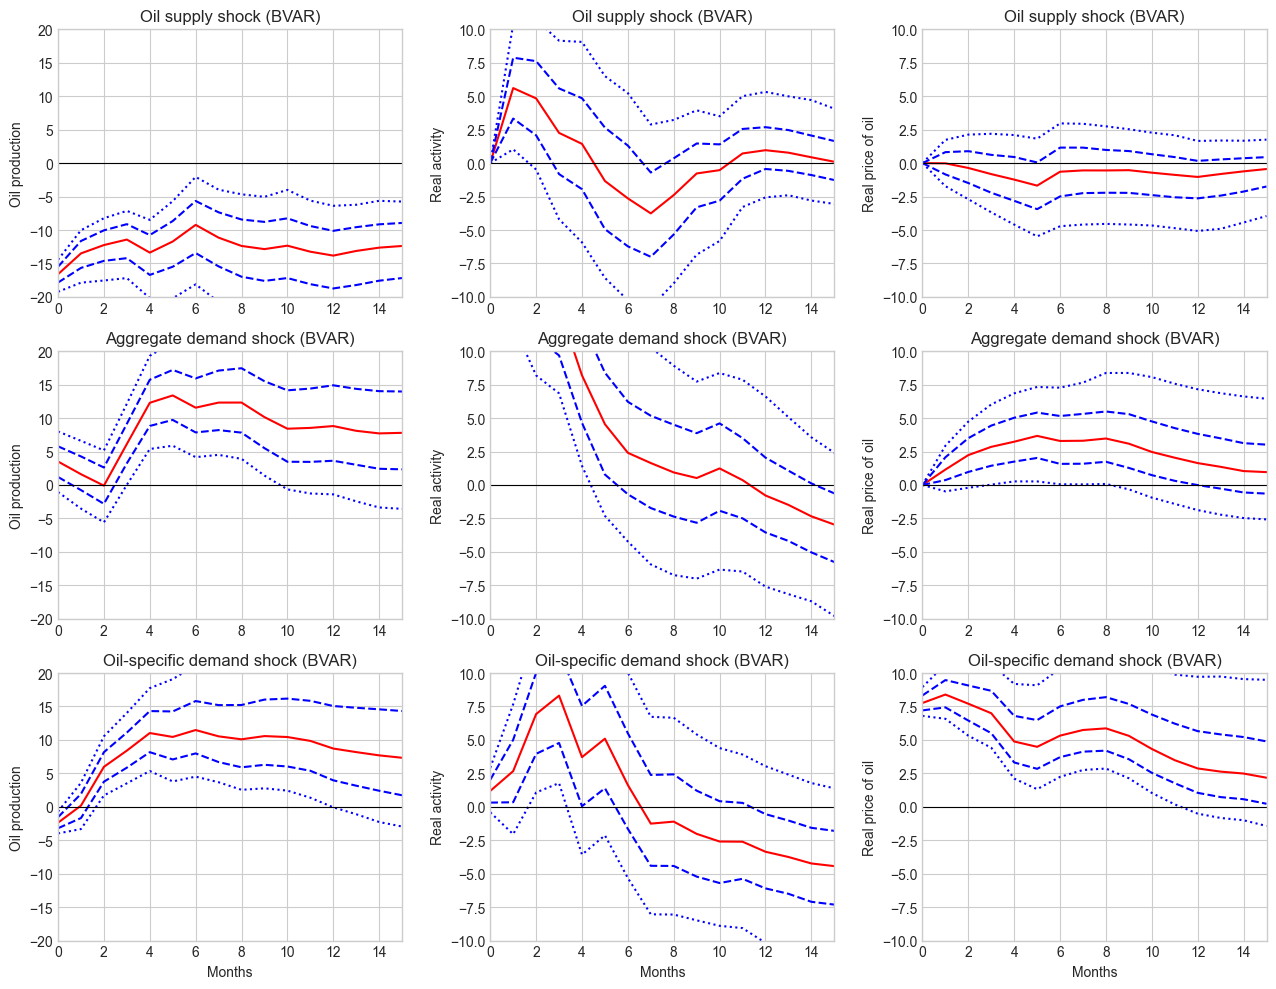

In [ ]:
# Posterior draw IRFs for credible bands
n_keep = bvar['B_draws'].shape[0]
max_draws = min(2000, n_keep)
idx = np.linspace(0, n_keep - 1, max_draws, dtype=int)

IRF_draws = np.zeros((max_draws, n * n, h + 1))
for j, d in enumerate(idx):
    B_d = bvar['B_draws'][d]
    S_d = bvar['Sigma_draws'][d]
    _, _, A_comp_d = bvar_state_matrices(B_d, n=n, p=p)
    irf_d = irf_from_companion(A_comp_d, S_d, n=n, p=p, h=h)
    irf_d[0, :] = np.cumsum(irf_d[0, :])
    irf_d[3, :] = np.cumsum(irf_d[3, :])
    irf_d[6, :] = np.cumsum(irf_d[6, :])
    IRF_draws[j] = irf_d

IRF_med = np.median(IRF_draws, axis=0)
IRF_68 = np.quantile(IRF_draws, [0.16, 0.84], axis=0)
IRF_95 = np.quantile(IRF_draws, [0.025, 0.975], axis=0)

horizon = np.arange(0, h + 1)
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.ravel()

meta = [
    ('Oil supply shock (BVAR)', 'Oil production', (-20, 20), -1), 
    ('Oil supply shock (BVAR)', 'Real activity', (-10, 10), -1),
    ('Oil supply shock (BVAR)', 'Real price of oil', (-10, 10), -1),
    ('Aggregate demand shock (BVAR)', 'Oil production', (-20, 20), 1),
    ('Aggregate demand shock (BVAR)', 'Real activity', (-10, 10), 1),
    ('Aggregate demand shock (BVAR)', 'Real price of oil', (-10, 10), 1),
    ('Oil-specific demand shock (BVAR)', 'Oil production', (-20, 20), 1),
    ('Oil-specific demand shock (BVAR)', 'Real activity', (-10, 10), 1),
    ('Oil-specific demand shock (BVAR)', 'Real price of oil', (-10, 10), 1),
]

print(f"IRFs at horizon {h}")
for i, (ttl, yl, ylim, sgn) in enumerate(meta):
    ax = axes[i]
    m = sgn * IRF_med[i]
    l68, u68 = sgn * IRF_68[0, i], sgn * IRF_68[1, i]
    l95, u95 = sgn * IRF_95[0, i], sgn * IRF_95[1, i]
    lo68, hi68 = np.minimum(l68, u68), np.maximum(l68, u68)
    lo95, hi95 = np.minimum(l95, u95), np.maximum(l95, u95)

    ax.plot(horizon, m, 'r-')
    ax.plot(horizon, lo68, 'b--')
    ax.plot(horizon, hi68, 'b--')
    ax.plot(horizon, lo95, 'b:')
    ax.plot(horizon, hi95, 'b:')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(ttl)
    ax.set_ylabel(yl)
    ax.set_xlim(0, h)
    ax.set_ylim(*ylim)
    if i >= 6:
        ax.set_xlabel('Months')

plt.tight_layout()
plt.show()

# 4.1 FEVD

FEVD at horizon 15


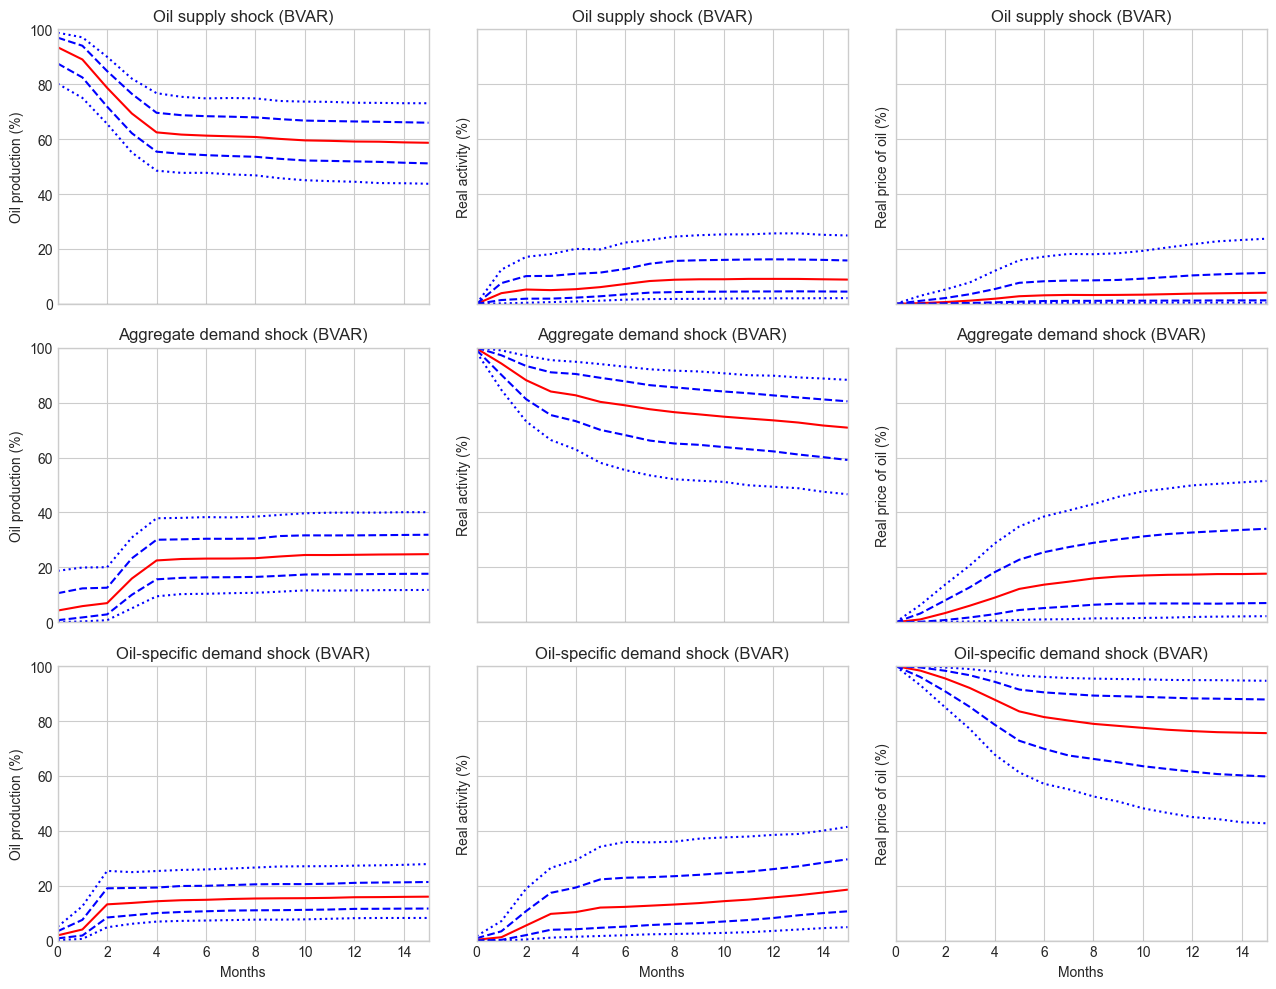

FEVD verification (should sum to ~100% for each variable at each horizon):
Oil production: h=0: 99.6%, h=6: 99.3%, h=15: 99.5%
Real activity: h=0: 100.0%, h=6: 98.5%, h=15: 98.3%
Real price of oil: h=0: 100.0%, h=6: 98.2%, h=15: 97.3%


In [99]:
# FEVD: posterior draws + credible bands
n_keep = bvar['B_draws'].shape[0]
max_draws = min(2000, n_keep)
idx = np.linspace(0, n_keep - 1, max_draws, dtype=int)

# FEVD_draws[d, shock, variable, horizon]
FEVD_draws = np.zeros((max_draws, n, n, h + 1))

for j, d in enumerate(idx):
    B_d = bvar['B_draws'][d]
    S_d = bvar['Sigma_draws'][d]
    _, _, A_comp_d = bvar_state_matrices(B_d, n=n, p=p)
    irf_d = irf_from_companion(A_comp_d, S_d, n=n, p=p, h=h)

    # irf_d uses order='F': [var1_shock1, var2_shock1, var3_shock1, var1_shock2, ...]
    # Reshape to (variable, shock, horizon) then transpose to (shock, variable, horizon)
    psi = irf_d.reshape(n, n, h + 1, order='F').transpose(1, 0, 2)

    # cumulative squared impulse responses up to horizon t
    cum_sq = np.cumsum(psi ** 2, axis=2)
    denom = np.sum(cum_sq, axis=0, keepdims=True)

    # avoid divide-by-zero at very early horizons
    FEVD_draws[j] = np.divide(cum_sq, denom, out=np.zeros_like(cum_sq), where=denom > 0)

FEVD_med = np.median(FEVD_draws, axis=0)
FEVD_68 = np.quantile(FEVD_draws, [0.16, 0.84], axis=0)
FEVD_95 = np.quantile(FEVD_draws, [0.025, 0.975], axis=0)

horizon = np.arange(0, h + 1)
fig, axes = plt.subplots(3, 3, figsize=(13, 10), sharex=True, sharey=True)
axes = axes.ravel()

meta = [
    ('Oil supply shock (BVAR)', 'Oil production'),
    ('Oil supply shock (BVAR)', 'Real activity'),
    ('Oil supply shock (BVAR)', 'Real price of oil'),
    ('Aggregate demand shock (BVAR)', 'Oil production'),
    ('Aggregate demand shock (BVAR)', 'Real activity'),
    ('Aggregate demand shock (BVAR)', 'Real price of oil'),
    ('Oil-specific demand shock (BVAR)', 'Oil production'),
    ('Oil-specific demand shock (BVAR)', 'Real activity'),
    ('Oil-specific demand shock (BVAR)', 'Real price of oil'),
]

print(f"FEVD at horizon {h}")
for k, (ttl, yl) in enumerate(meta):
    shock = k // n
    var = k % n

    med = 100.0 * FEVD_med[shock, var]
    l68 = 100.0 * FEVD_68[0, shock, var]
    u68 = 100.0 * FEVD_68[1, shock, var]
    l95 = 100.0 * FEVD_95[0, shock, var]
    u95 = 100.0 * FEVD_95[1, shock, var]

    lo68, hi68 = np.minimum(l68, u68), np.maximum(l68, u68)
    lo95, hi95 = np.minimum(l95, u95), np.maximum(l95, u95)

    ax = axes[k]
    ax.plot(horizon, med, 'r-')
    ax.plot(horizon, lo68, 'b--')
    ax.plot(horizon, hi68, 'b--')
    ax.plot(horizon, lo95, 'b:')
    ax.plot(horizon, hi95, 'b:')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(ttl)
    ax.set_ylabel(f"{yl} (%)")
    ax.set_xlim(0, h)
    ax.set_ylim(0, 100)
    if k >= 6:
        ax.set_xlabel('Months')

plt.tight_layout()
plt.show()

# Verification: FEVD should sum to 100% across shocks for each variable
print("FEVD verification (should sum to ~100% for each variable at each horizon):")
for var in range(n):
    var_names = ['Oil production', 'Real activity', 'Real price of oil']
    fevd_sum = np.sum(FEVD_med[:, var, :], axis=0) * 100
    print(f"{var_names[var]}: h=0: {fevd_sum[0]:.1f}%, h=6: {fevd_sum[6]:.1f}%, h=15: {fevd_sum[15]:.1f}%")


In [100]:
# Granger causality tests (lag p=24, same as BVAR)
from IPython.display import display
from statsmodels.tsa.stattools import grangercausalitytests

var_names = ['d_prod', 'rea', 'rpo']
var_labels = {
    'd_prod': 'oil production (d_prod)',
    'rea': 'real activity (rea)',
    'rpo': 'real price of oil (rpo)',
}

# Bivariate tests: H0 = x does NOT Granger-cause y
# statsmodels: column 2 Granger-causes column 1 in [y, x]
bivariate_tests = [
    ('rea', 'd_prod', 'd_prod → rea'),
    ('rpo', 'd_prod', 'd_prod → rpo'),
    ('d_prod', 'rea', 'rea → d_prod'),
    ('rpo', 'rea', 'rea → rpo'),
    ('rea', 'rpo', 'rpo → rea'),
    ('d_prod', 'rpo', 'rpo → d_prod'),
]

bi_rows = []
for y_col, x_col, label in bivariate_tests:
    arr = df[[y_col, x_col]].values
    res = grangercausalitytests(arr, maxlag=[p], verbose=False)
    fstat, pval, df_denom, df_num = res[p][0]['ssr_ftest']
    bi_rows.append({
        'direction': label,
        'cause': var_labels[x_col],
        'effect': var_labels[y_col],
        'F_stat': fstat,
        'p_value': pval,
        'reject_5pct': pval < 0.05,
    })

bivariate_gc = pd.DataFrame(bi_rows)
print('Bivariate Granger causality (H0: no causality) H0: lags of "cause" do not help predict "effect"')
display(bivariate_gc.style.format({'F_stat': '{:.3f}', 'p_value': '{:.4f}'}))

# Multivariate tests: H0 = lags of "cause" do not help predict all other variables
var_ols = VAR(df[var_names]).fit(p)
mv_rows = []
for cause in var_names:
    caused = [c for c in var_names if c != cause]
    tc = var_ols.test_causality(caused=caused, causing=cause)
    mv_rows.append({
        'cause': var_labels[cause],
        'effect': 'all other variables',
        'F_stat': tc.test_statistic,
        'p_value': tc.pvalue,
        'reject_5pct': tc.pvalue < 0.05,
    })

multivariate_gc = pd.DataFrame(mv_rows)
print('\nMultivariate Granger causality (conditional on full VAR) H0: lags of "cause" do not help predict all other variables')
display(multivariate_gc.style.format({'F_stat': '{:.3f}', 'p_value': '{:.4f}'}))

# Pairwise FEVD at h=15 for comparison (median across posterior draws if FEVD_med exists)
if 'FEVD_med' in globals():
    h_fevd = FEVD_med.shape[2] - 1
    fevd_h = 100 * FEVD_med[:, :, h_fevd]
    fevd_diag = pd.Series(
        {var_labels[var_names[i]]: fevd_h[i, i] for i in range(n)},
        name=f'own-shock FEVD at h={h_fevd} (%)',
    )
    print(f'\nDiagonal FEVD shares at horizon h={h_fevd} (posterior median):')
    display(fevd_diag.to_frame())


Bivariate Granger causality (H0: no causality) H0: lags of "cause" do not help predict "effect"


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since fu

,direction,cause,effect,F_stat,p_value,reject_5pct
0,d_prod → rea,oil production (d_prod),real activity (rea),0.520,0.7915,False
1,d_prod → rpo,oil production (d_prod),real price of oil (rpo),0.800,0.5732,False
2,rea → d_prod,real activity (rea),oil production (d_prod),2.979,0.0115,True
3,rea → rpo,real activity (rea),real price of oil (rpo),0.928,0.4801,False
4,rpo → rea,real price of oil (rpo),real activity (rea),2.032,0.0717,False
5,rpo → d_prod,real price of oil (rpo),oil production (d_prod),3.773,0.0025,True



Multivariate Granger causality (conditional on full VAR) H0: lags of "cause" do not help predict all other variables


,cause,effect,F_stat,p_value,reject_5pct
0,oil production (d_prod),all other variables,0.670,0.7794,False
1,real activity (rea),all other variables,1.966,0.0288,True
2,real price of oil (rpo),all other variables,2.768,0.0016,True



Diagonal FEVD shares at horizon h=15 (posterior median):


,own-shock FEVD at h=15 (%)
oil production (d_prod),58.670198
real activity (rea),70.883482
real price of oil (rpo),75.586049


## Bayesian Figure 4: cumulative effect on real oil price

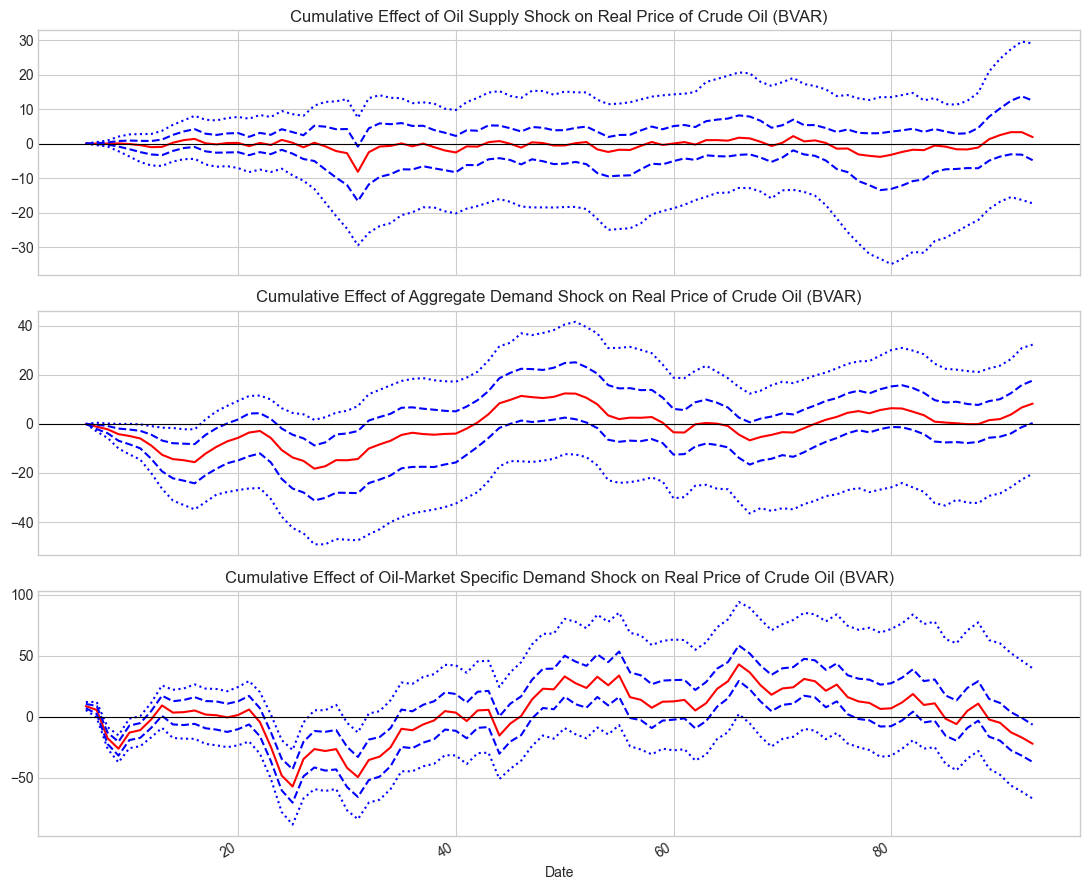

In [101]:
oil_ci = posterior_draw_CI(y, bvar['B_draws'], bvar['Sigma_draws'], p=p, n=n)

# Date axis aligned to the actual data: first shock date is df.index[p]
time_dates = df.index[p:]

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

titles = [
    'Cumulative Effect of Oil Supply Shock on Real Price of Crude Oil (BVAR)',
    'Cumulative Effect of Aggregate Demand Shock on Real Price of Crude Oil (BVAR)',
    'Cumulative Effect of Oil-Market Specific Demand Shock on Real Price of Crude Oil (BVAR)',
]
for shock, ax in enumerate(axes):
    m = oil_ci['median'][shock]
    l68, u68 = oil_ci['q68'][0, shock], oil_ci['q68'][1, shock]
    l95, u95 = oil_ci['q95'][0, shock], oil_ci['q95'][1, shock]
    lo68, hi68 = np.minimum(l68, u68), np.maximum(l68, u68)
    lo95, hi95 = np.minimum(l95, u95), np.maximum(l95, u95)

    ax.plot(time_dates, m, 'r-')
    ax.plot(time_dates, lo68, 'b--')
    ax.plot(time_dates, hi68, 'b--')
    ax.plot(time_dates, lo95, 'b:')
    ax.plot(time_dates, hi95, 'b:')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(titles[shock])
    # ax.set_ylim(-200, 200)

axes[-1].set_xlabel('Date')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## Bayesian Figure 5-style responses: shocks on real GDP and CPI

In [102]:
# Load merged GDP and CPI data (Kilian's original 1974-2007 + extension 2008-2025)
# These files were created by fetching GDPC1 and CPIAUCSL from FRED

# GDP: quarterly real GDP in billions of chained dollars
beagdp_merged = np.loadtxt(BASE_DIR / 'data/beagdp_merged_1974_2025.txt')
print("GDP data loaded:")
print(f"  Range: {int(beagdp_merged[0,0])} Q{int(beagdp_merged[0,1])} → "
      f"{int(beagdp_merged[-1,0])} Q{int(beagdp_merged[-1,1])}")
print(f"  Quarters: {len(beagdp_merged)}")

# CPI: monthly CPI-U (all urban consumers)
cpi_merged = np.loadtxt(BASE_DIR / 'data/cpi_merged_1974_2025.txt')
print("\nCPI data loaded:")
print(f"  Range: {int(cpi_merged[0,0])}-{int(cpi_merged[0,1]):02d} → "
      f"{int(cpi_merged[-1,0])}-{int(cpi_merged[-1,1]):02d}")
print(f"  Months: {len(cpi_merged)}") 


NameError: name 'BASE_DIR' is not defined


Stage-2 alignment:
  Quarterly shocks : 203 quarters (q1q, q2q, q3q)
  GDP growth       : 203 quarters
  CPI inflation    : 202 quarters
  First quarter    : 1975 Q1
  Used for GDP stage-2: 203 quarters
  Used for CPI stage-2: 202 quarters


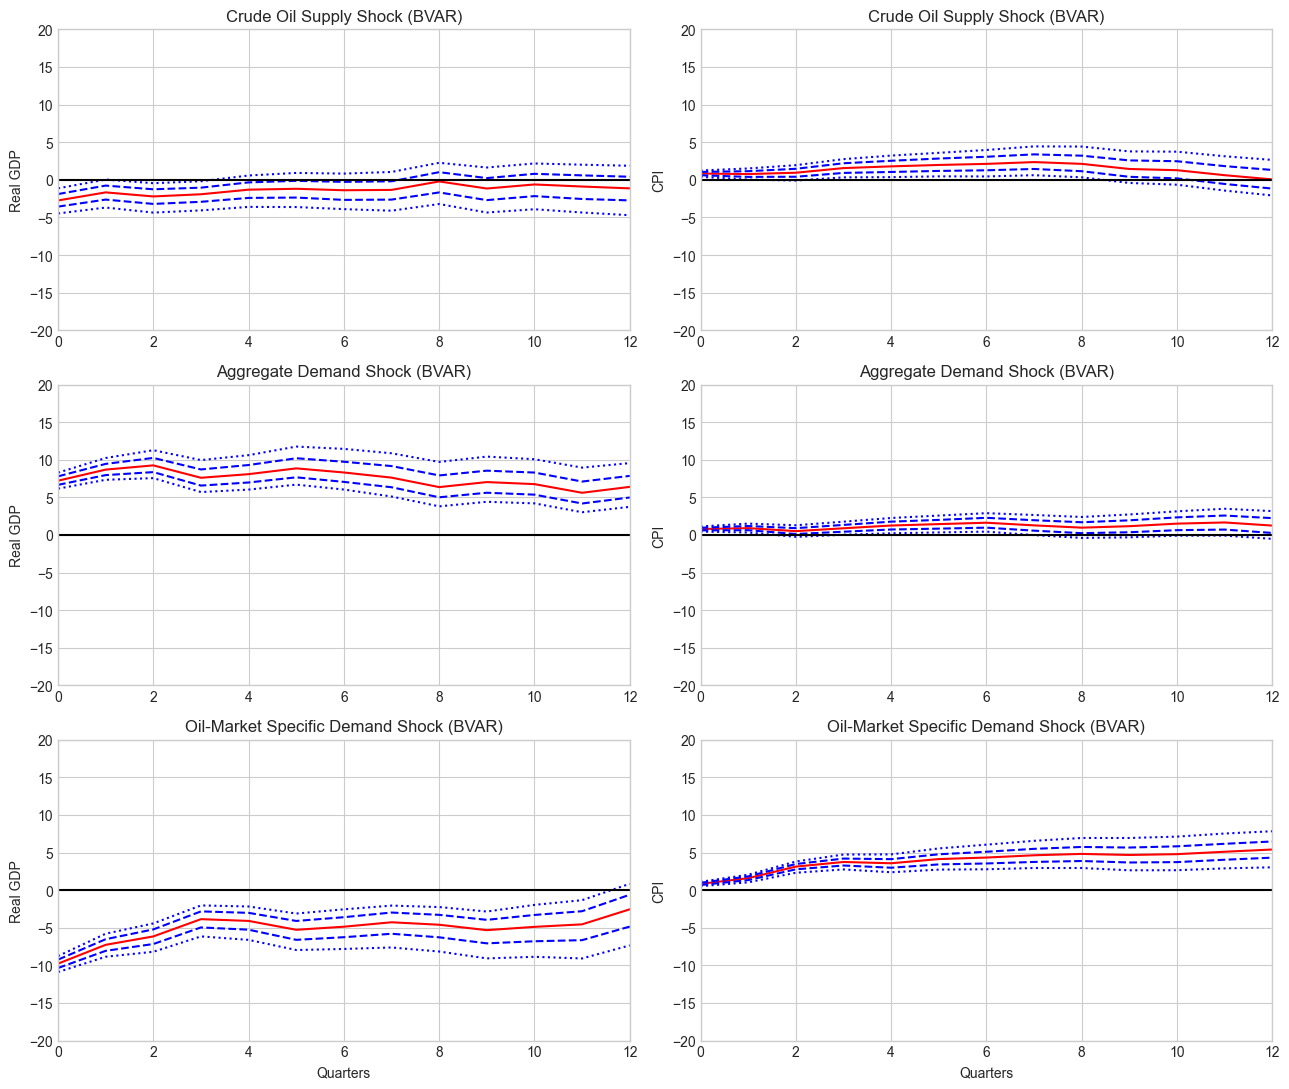

In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
# Stage-2 setup: quarterly oil shocks → GDP growth and CPI inflation
# ═════════════════════════════════════════════════════════════════════════════

# Quarterly average structural shocks from monthly BVAR estimates
shock_dates = df.index[p:]  # first shock: 2010-01 (after p=24 lags from 2008-01)

# Pad with initial value (Kilian convention: average first two months)
q1 = np.concatenate([[(Ehat_b[0, 0] + Ehat_b[0, 1]) / 2], Ehat_b[0, :]])
q2 = np.concatenate([[(Ehat_b[1, 0] + Ehat_b[1, 1]) / 2], Ehat_b[1, :]])
q3 = np.concatenate([[(Ehat_b[2, 0] + Ehat_b[2, 1]) / 2], Ehat_b[2, :]])

# Quarterly averages (drop incomplete trailing months)
nq = len(q1) // 3
q1q = q1[:3 * nq].reshape(-1, 3).mean(axis=1)
q2q = q2[:3 * nq].reshape(-1, 3).mean(axis=1)
q3q = q3[:3 * nq].reshape(-1, 3).mean(axis=1)

# ─────────────────────────────────────────────────────────────────────────────
# GDP growth rate (quarterly, annualized %)
# ─────────────────────────────────────────────────────────────────────────────
gdp_vals = beagdp_merged[:, 2]  # column 3: real GDP
y_gdp_full = (np.log(gdp_vals[1:]) - np.log(gdp_vals[:-1])) * 400

# Align with quarterly shocks: first shock quarter is 2010 Q1
first_shock_year = shock_dates[0].year
first_shock_qtr = (shock_dates[0].month - 1) // 3 + 1

gdp_start_year = int(beagdp_merged[0, 0])
gdp_start_qtr = int(beagdp_merged[0, 1])

# Quarters from GDP start to first shock
offset_q = (first_shock_year - gdp_start_year) * 4 + (first_shock_qtr - gdp_start_qtr)

# Extract aligned GDP growth (same length as quarterly shocks)
y_gdp = y_gdp_full[offset_q - 1 : offset_q - 1 + nq, None]

# ─────────────────────────────────────────────────────────────────────────────
# CPI inflation rate (quarterly, annualized %)
# ─────────────────────────────────────────────────────────────────────────────
cpi_vals = cpi_merged[:, 2]
cpi_log = np.log(cpi_vals)

# Quarterly inflation: (log(CPI_end) - log(CPI_start)) × 400 for each quarter
first_cpi_idx = offset_q * 3  # months from CPI start to first shock quarter

infl_q = []
for i in range(nq):
    idx_start = first_cpi_idx + i * 3
    idx_end = idx_start + 3
    if idx_end < len(cpi_log) and not np.isnan(cpi_vals[idx_end]):
        infl_q.append((cpi_log[idx_end] - cpi_log[idx_start]) * 400)
    else:
        # Hit NaN or end of data — stop here
        break

y_cpi = np.array(infl_q)[:, None]

print(f"\nStage-2 alignment:")
print(f"  Quarterly shocks : {nq} quarters (q1q, q2q, q3q)")
print(f"  GDP growth       : {y_gdp.shape[0]} quarters")
print(f"  CPI inflation    : {y_cpi.shape[0]} quarters")
print(f"  First quarter    : {first_shock_year} Q{first_shock_qtr}")

# Align lengths explicitly for stage-2 regressions
nq_gdp = min(len(q1q), y_gdp.shape[0])
nq_cpi = min(len(q1q), y_cpi.shape[0])

y_gdp_use = y_gdp[:nq_gdp]
y_cpi_use = y_cpi[:nq_cpi]

print(f"  Used for GDP stage-2: {nq_gdp} quarters")
print(f"  Used for CPI stage-2: {nq_cpi} quarters")

# Stage-2 responses: posterior credible bands (reuses Ehat_draws from oil_ci)
if 'oil_ci' not in globals():
    oil_ci = posterior_draw_CI(y, bvar['B_draws'], bvar['Sigma_draws'], p=p, n=n)

Ehat_draws = oil_ci['Ehat_draws']
r2 = stage2_posterior_ci(y_gdp_use, Ehat_draws, shock_idx=0, nq=nq_gdp)
r3 = stage2_posterior_ci(y_gdp_use, Ehat_draws, shock_idx=1, nq=nq_gdp)
r4 = stage2_posterior_ci(y_gdp_use, Ehat_draws, shock_idx=2, nq=nq_gdp)

c2 = stage2_posterior_ci(y_cpi_use, Ehat_draws, shock_idx=0, nq=nq_cpi)
c3 = stage2_posterior_ci(y_cpi_use, Ehat_draws, shock_idx=1, nq=nq_cpi)
c4 = stage2_posterior_ci(y_cpi_use, Ehat_draws, shock_idx=2, nq=nq_cpi)

h2 = np.arange(13)
fig, axes = plt.subplots(3, 2, figsize=(13, 11))

# GDP panels
for ax, rr, ttl, sgn in [
    (axes[0, 0], r2, 'Crude Oil Supply Shock (BVAR)', -1),
    (axes[1, 0], r3, 'Aggregate Demand Shock (BVAR)', 1),
    (axes[2, 0], r4, 'Oil-Market Specific Demand Shock (BVAR)', 1),
]:
    m = sgn * rr['cum']
    lo68 = sgn * rr['cum_68'][0]
    hi68 = sgn * rr['cum_68'][1]
    lo95 = sgn * rr['cum_95'][0]
    hi95 = sgn * rr['cum_95'][1]
    a68, b68 = np.minimum(lo68, hi68), np.maximum(lo68, hi68)
    a95, b95 = np.minimum(lo95, hi95), np.maximum(lo95, hi95)

    ax.plot(h2, m, 'r-')
    ax.plot(h2, a68, 'b--')
    ax.plot(h2, b68, 'b--')
    ax.plot(h2, a95, 'b:')
    ax.plot(h2, b95, 'b:')
    ax.plot(h2, np.zeros_like(h2), 'k-')
    ax.set_xlim(0, 12)
    ax.set_ylim(-20, 20)
    ax.set_ylabel('Real GDP')
    ax.set_title(ttl)
axes[2, 0].set_xlabel('Quarters')

# CPI panels
for ax, rr, ttl, sgn in [
    (axes[0, 1], c2, 'Crude Oil Supply Shock (BVAR)', -1),
    (axes[1, 1], c3, 'Aggregate Demand Shock (BVAR)', 1),
    (axes[2, 1], c4, 'Oil-Market Specific Demand Shock (BVAR)', 1),
]:
    m = sgn * rr['cum']
    lo68 = sgn * rr['cum_68'][0]
    hi68 = sgn * rr['cum_68'][1]
    lo95 = sgn * rr['cum_95'][0]
    hi95 = sgn * rr['cum_95'][1]
    a68, b68 = np.minimum(lo68, hi68), np.maximum(lo68, hi68)
    a95, b95 = np.minimum(lo95, hi95), np.maximum(lo95, hi95)

    ax.plot(h2, m, 'r-')
    ax.plot(h2, a68, 'b--')
    ax.plot(h2, b68, 'b--')
    ax.plot(h2, a95, 'b:')
    ax.plot(h2, b95, 'b:')
    ax.plot(h2, np.zeros_like(h2), 'k-')
    ax.set_xlim(0, 12)
    ax.set_ylim(-20, 20)
    ax.set_ylabel('CPI')
    ax.set_title(ttl)
axes[2, 1].set_xlabel('Quarters')

plt.tight_layout()
plt.show()